# Introduction to Machine Learning -- MC886
# Assignment 1 - Linear Models

**Professor:** Marcelo da Silva Reis\
**PED:** Daniel Gardin Gratti\
**PAD:** Guilherme Henrique Ichiro Seto Ito


In [1]:
# Please, enter your name and RA number in the lines below:
print("Student 1", "Caio Azevedo Dal Porto", "256709")
print("Student 2", "Vinicius Leme Soares", "260727")

Student 1 Caio Azevedo Dal Porto 256709
Student 2 Vinicius Leme Soares 260727



## Objective

The objective with this assignment is to explore **Linear Regression** and other
**Generalized Linear Models** to come up with the best model for the problem.
Rememberm the goal is not just getting the code running, but gathering a deeper
understanding on **how** these algorithms work and **why** choosing them in the
first place.

Every model choice has implicit assumptions about the data, the goal here is to
understand the underlying assumptions and critically address the limitations
introduced by them.

### **Guidelines**
> Please, read these guidelines carefully

1. The questions can be answered in English or in Portuguese.

2. We incentivize visualizing the (training) data to gather insight about the
problem and the solutions. If you are not sure about an assumption, plot it!

3. The existing code in this notebook is just a mere reference. You are free to
change the code as much as you need. You will not be penalized for changing a 
function signature or implementing more functions/classes.
**Just make the code readable!**

4. The use of generative AI (ChatGPT, DeepSeek, Llama, GitHub Copilot, etc.) is
permitted to assist in completing assignments. In such cases the submitted work
**must** include a statement specifying the models used and, if
applicable, a transcription of the prompts employed to generate the code
incorporated into the solution.
However, using AI to analyse and discuss the results is discouraged.

5. The final performance of your model is not the main goal, explaining why the
model has such a performance (it being good or bad) is more important than the
metric value per se.

6. Metrics are not detached values, revisit the math behind them to understand
what they are trying to say about your model.

7. Do not hesitate in reaching the PED/PAD via Discord.

---
### **Dataset**
The dataset we will be using is the [Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)
dataset, an hourly count of rental bikes between 2011 and 2012 in Washington, D.C..

The data has 17379 samples with the following columns

feature | description | data type
--- | --- | ---
**instant** | Integer identifier | Integer
**dteday** | Datetime of the instant | Date
**season** | The season (Winter, Spring, Summer and Fall) | Categorical
**yr** | Year (0 for 2011 and 1 for 2012) | Categorical
**mnth** | The month number | Categorical
**hr** | The hour number | Categorical
**holiday** | Whether the day is a holiday or not | Boolean
**weekday** | The day of the week | Categorical
**workingday** | If the day is neither a holiday nor a weekend | Boolean
**weathersit** | Current weather (Clear, Few clouds, Partly cloudy, Cloudy) | Categorical
**temp** | Temperature in °C | Continuous
**atemp** | Feeling temperature in °C | Continuous
**hum** | Humidity in % | Continuous
**windspeed** | Wind speed in km/h | Continuous
**casual** | Count of casual users | Integer
**registered** | Count of registered users | Integer
**cnt** | Count of total bikes (casual + registered) | Integer

The goal will be inferring the number of rental bikes only using datetime and
weather information provided in the dataset.

In [2]:
# Importing the necessary libraries
# Remember to re-visit the Hands-on 1 notebooks to setup your environment
from numpy.typing import NDArray
import numpy as np

import pandas as pd
import random

# This notebook already has some plot examples in matplotlib, but feel free to
# use other libraries (e.g., seaborn, plotly) if you prefer
import matplotlib.pyplot as plt

# To ensure reproducibility, set the random seed to your
# favorite number (e.g., your RA number)
np.random.seed(42)
random.seed(42)

# Do not tune this number to get better results, it is just to ensure that
# we all have the same random numbers and, therefore, the same results
# Re-run the notebook from the beginning (Run All) before submitting to classroom

In [26]:
# The dataset is available in the classroom assignment, ensure you have downloaded
# it and placed it in the same folder as this notebook

# Load the dataset
df = pd.read_csv("bike_share.csv")

df["dteday"] = pd.to_datetime(df["dteday"])
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,3.28,3.0014,81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,2.34,1.9982,80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,2.34,1.9982,80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,3.28,3.0014,75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,3.28,3.0014,75,0.0,0,1,1


Note that the data is time-ordered, each sample has a 1 hour gap between each other.
The idea is to predict future rental count from past data, thus our evaluation
protocol must respect the temporal order.
Therefore, we select the first 80% samples to compose the training data, and the
remaining 20% will be used for testing pourposes.

**Important:** Never take decisions over the test dataset, it must be only used after
all models are trained (in the Test Evaluation section).
Any decision made using test information is called [data leakage](https://en.wikipedia.org/wiki/Leakage_(machine_learning)) and will be penalized.

In [27]:
train_size = int(0.8 * len(df))

train_df = df[:train_size]
test_df = df[train_size:]

# Securing that df will not be used anymore, to avoid mistakes
del df

print("Train set size:", len(train_df))
print("Test set size:", len(test_df))

Train set size: 13903
Test set size: 3476


---

## **Data Analysis and Preprocessing**

This part of the assignment aims to analyze the dataset and preprocess
the data for the models.


(0.5 points) 
First, consider possible problems in your dataset:
- Should you use all the features in the dataset?
- What features are important, are there missing values in them?
- Are there outliers in continous features?
- How should you handle the categorical features?
- How does the rental count change when features change?
- Are these feature correlated?

Do not plot any graph for now, just see some statistics (mean, count, data types).
You can manually explore the dataframe if you want.

In [6]:
train_df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,13903.000000,13903,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000,13903.000000
mean,6952.000000,2011-10-21 10:31:11.078184,2.263828,0.378192,5.650147,11.546573,0.027404,2.999425,0.684457,1.419981,15.460988,15.549146,62.299576,13.004472,34.037977,140.601165,174.639143
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-7.060000,-16.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3476.500000,2011-05-29 00:00:00,1.000000,0.000000,3.000000,6.000000,0.000000,1.000000,0.000000,1.000000,7.980000,5.997800,47.000000,7.001500,4.000000,31.000000,37.000000
50%,6952.000000,2011-10-22 00:00:00,2.000000,0.000000,5.000000,12.000000,0.000000,3.000000,1.000000,1.000000,15.500000,15.996800,62.000000,12.998000,15.000000,107.000000,130.000000
75%,10427.500000,2012-03-15 00:00:00,3.000000,1.000000,8.000000,18.000000,0.000000,5.000000,1.000000,2.000000,23.020000,24.999200,79.000000,19.001200,46.000000,202.000000,258.000000
max,13903.000000,2012-08-07 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,39.000000,50.000000,100.000000,56.996900,367.000000,796.000000,957.000000
std,4013.594731,NaN,1.036254,0.484953,3.218423,6.912235,0.163264,2.005710,0.464749,0.644060,9.292659,11.656519,19.819432,8.242555,47.341186,137.512367,166.955414


In [7]:
train_df['instant'], train_df['dteday']

(0            1
 1            2
 2            3
 3            4
 4            5
          ...  
 13898    13899
 13899    13900
 13900    13901
 13901    13902
 13902    13903
 Name: instant, Length: 13903, dtype: int64,
 0       2011-01-01
 1       2011-01-01
 2       2011-01-01
 3       2011-01-01
 4       2011-01-01
            ...    
 13898   2012-08-07
 13899   2012-08-07
 13900   2012-08-07
 13901   2012-08-07
 13902   2012-08-07
 Name: dteday, Length: 13903, dtype: datetime64[us])

In [8]:
train_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
print(train_df['season'].value_counts())
print(train_df['yr'].value_counts())
print(train_df['mnth'].value_counts())
print(train_df['hr'].value_counts())
print(train_df['weekday'].value_counts())
print(train_df['weathersit'].value_counts())

season
2    4409
1    3980
3    3380
4    2134
Name: count, dtype: int64
yr
0    8645
1    5258
Name: count, dtype: int64
mnth
5     1488
7     1488
3     1473
6     1440
4     1437
1     1429
2     1341
8      887
10     743
12     741
11     719
9      717
Name: count, dtype: int64
hr
16    584
17    584
7     583
8     583
9     583
10    583
11    583
12    583
13    583
14    583
15    583
18    582
19    582
20    582
21    582
22    582
23    582
0     581
6     581
1     580
5     573
2     571
3     556
4     554
Name: count, dtype: int64
weekday
6    2008
1    1999
0    1998
5    1983
2    1975
3    1971
4    1969
Name: count, dtype: int64
weathersit
1    9251
2    3468
3    1181
4       3
Name: count, dtype: int64


In [10]:
train_df.corr()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,0.999993,0.176577,0.839933,0.193065,-0.007760,0.001427,-0.001694,0.005468,-0.047467,0.277720,0.280882,-0.030960,-0.051585,0.204178,0.293063,0.299277
dteday,0.999993,1.000000,0.177469,0.839368,0.194090,-0.009495,0.001394,-0.001666,0.005556,-0.047302,0.278088,0.281287,-0.030037,-0.051841,0.203831,0.292509,0.298722
season,0.176577,0.177469,1.000000,-0.309066,0.861784,-0.007902,-0.010850,-0.002038,0.011264,-0.019776,0.426424,0.428898,0.171537,-0.141939,0.121768,0.106236,0.122029
yr,0.839933,0.839368,-0.309066,1.000000,-0.368074,-0.005019,-0.001900,-0.008503,0.001956,-0.035066,0.065511,0.065467,-0.132205,0.030481,0.147279,0.236922,0.236901
mnth,0.193065,0.194090,0.861784,-0.368074,1.000000,-0.007393,0.005516,0.012594,0.006021,-0.018295,0.356578,0.362571,0.183779,-0.144995,0.084158,0.073322,0.084255
hr,-0.007760,-0.009495,-0.007902,-0.005019,-0.007393,1.000000,0.000431,-0.003697,0.001854,-0.025294,0.137681,0.132834,-0.274534,0.142789,0.303987,0.381464,0.400389
holiday,0.001427,0.001394,-0.010850,-0.001900,0.005516,0.000431,1.000000,-0.098802,-0.247221,-0.021899,-0.021535,-0.028618,-0.031837,0.017985,0.037781,-0.042873,-0.024599
weekday,-0.001694,-0.001666,-0.002038,-0.008503,0.012594,-0.003697,-0.098802,1.000000,0.032216,0.016781,-0.009270,-0.010465,-0.028834,0.004026,0.017854,0.014460,0.016973
workingday,0.005468,0.005556,0.011264,0.001956,0.006021,0.001854,-0.247221,0.032216,1.000000,0.052018,0.049974,0.053047,0.021399,-0.000331,-0.307405,0.131536,0.021173
weathersit,-0.047467,-0.047302,-0.019776,-0.035066,-0.018295,-0.025294,-0.021899,0.016781,0.052018,1.000000,-0.106476,-0.107798,0.425762,0.015524,-0.161300,-0.134319,-0.156369


> **Question:**
>
> Which of the previous questions can you properly answer without visualizing the data?
> What decisions can be made right now?

First, consider possible problems in your dataset:
- Should you use all the features in the dataset?
    - It does not make sense to incorporate 'dteday' into training, since this information is already available through the features 'yr', 'mnth', and 'hr'. Additionally, the model does not handle the pd.datetime type properly. Moreover, incorporating 'casual' and 'registered' into the training set would lead to data leakage, since they directly compose the label to be predicted.
- What features are important, are there missing values in them?
    - Initially, it is hard to define which are the most important features, but based on the correlation values between the feature and the label, we can highlight 'hr', 'temp', and 'atemp'. We can easily check that there are no missing values in the data by running train_df.isna().sum().
- Are there outliers in continous features?
    - Using the train_df.describe() output, the information indicates that the features (actually the label in this case) 'registered', 'casual', and 'cnt' have outliers (the maximum is considerably higher than the 75th percentile and the mean). The same happens, but more gradually, with the 'windspeed' and 'atemp' features.
- How should you handle the categorical features?
    - To avoid constructing a high number of columns, we can employ Target Encoding for features with more than 7 classes ('mnth' and 'yr'), and One Hot Encoding for the rest.
- How does the rental count change when features change?
    - It highly depends on the feature. The ones with a higher correlation with the label lead to more considerable changes when they vary.
- Are these feature correlated?
    - As intuitively expected, temporal features like 'instant' and 'yr' have a high correlation between themselves; 'casual' and 'registered' are correlated with 'cnt'; 'temp' and 'atemp' are highly correlated; and 'season' and 'mnth' as well.

---
(1.0 points) Now, explore the raw data, visualize their relationship with the target `cnt`.
You can use boxplots to understand feature distributions, histograms to observe
the count frequency, explore the temporal correlation.

There is no minimum/maximum requirements for the exploratory data analysis, plot
as many graphs as you need to gather information from your problem.
After plotting, write about your findings, formulate hypothesis about unseen
patterns and ponder about the data preprocessing step.

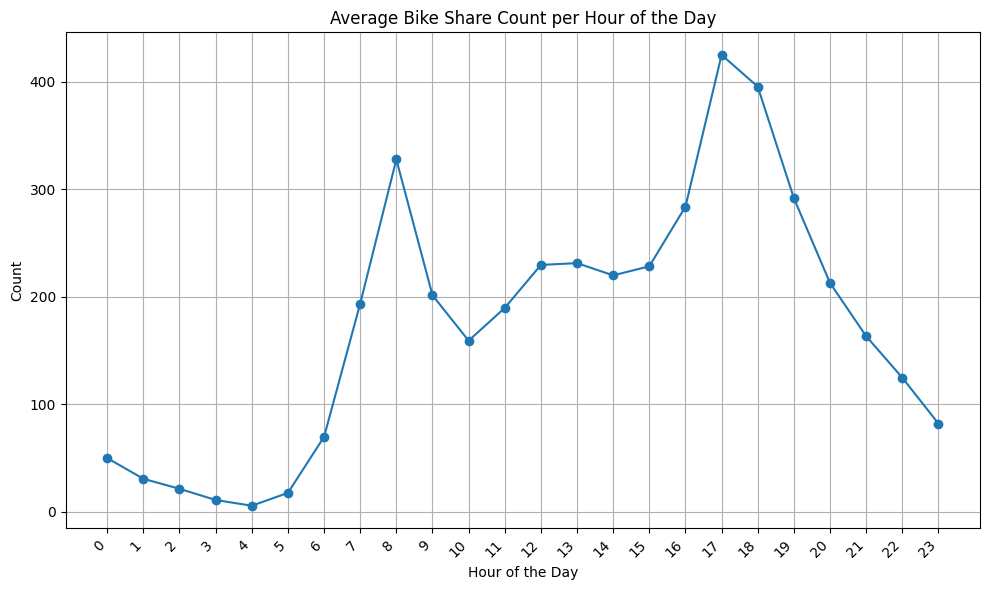

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.grid()

timestamp = train_df["dteday"] + pd.to_timedelta(train_df['hr'], unit='h')

# Mean count per hour of the day
hourly_counts = train_df.groupby("hr")["cnt"].mean()
ax.plot(hourly_counts.index, hourly_counts.values, marker="o")

ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Count")
ax.set_title("Average Bike Share Count per Hour of the Day")

plt.xticks(hourly_counts.index)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


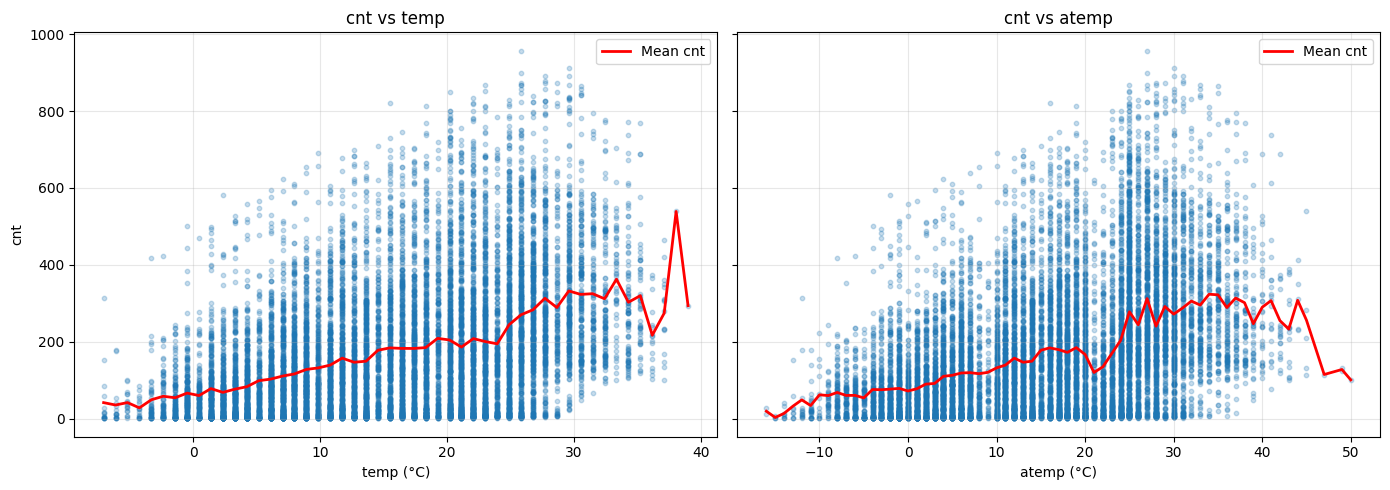

In [13]:
# Other visualizations here, e.g., histograms, boxplots, scatter plots, heatmaps, etc.
# Find the ones that you think are more interesting and relevant to understand the
# data and the problem at hand.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Scatter: cnt vs temp
axes[0].scatter(train_df["temp"], train_df["cnt"], alpha=0.25, s=10)
temp_mean = train_df.groupby("temp", as_index=False)["cnt"].mean().sort_values("temp")
axes[0].plot(temp_mean["temp"], temp_mean["cnt"], color="red", linewidth=2, label="Mean cnt")
axes[0].set_title("cnt vs temp")
axes[0].set_xlabel("temp (°C)")
axes[0].set_ylabel("cnt")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Scatter: cnt vs atemp
axes[1].scatter(train_df["atemp"], train_df["cnt"], alpha=0.25, s=10)
atemp_mean = train_df.groupby("atemp", as_index=False)["cnt"].mean().sort_values("atemp")
axes[1].plot(atemp_mean["atemp"], atemp_mean["cnt"], color="red", linewidth=2, label="Mean cnt")
axes[1].set_title("cnt vs atemp")
axes[1].set_xlabel("atemp (°C)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


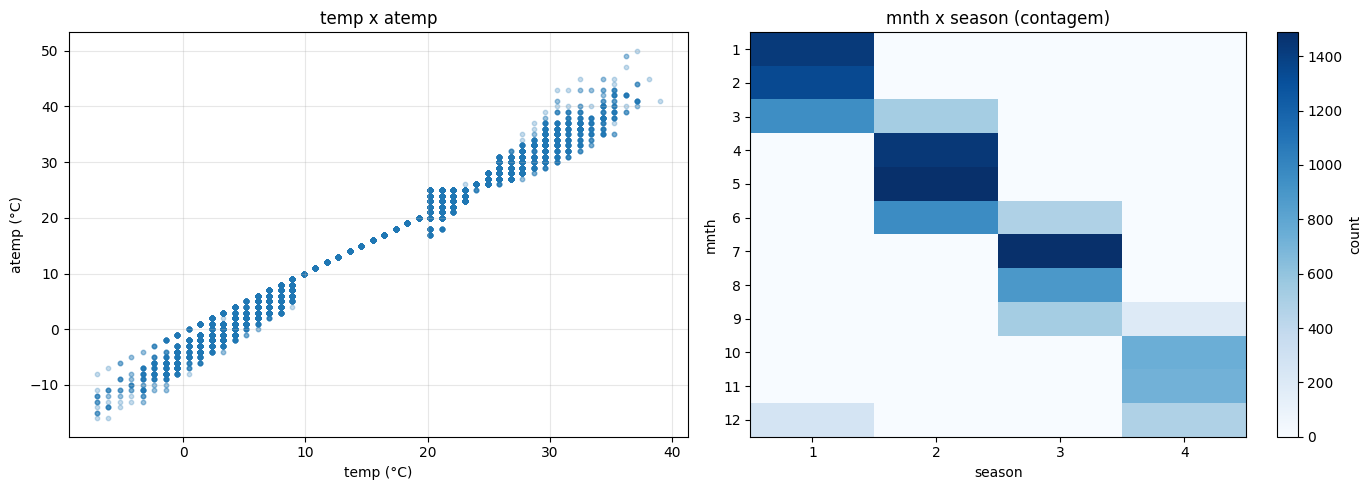

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) temp x atemp
axes[0].scatter(train_df["temp"], train_df["atemp"], alpha=0.25, s=10)
axes[0].set_title("temp x atemp")
axes[0].set_xlabel("temp (°C)")
axes[0].set_ylabel("atemp (°C)")
axes[0].grid(True, alpha=0.3)

# 2) mnth x season (frequência)
month_season = pd.crosstab(train_df["mnth"], train_df["season"])
im = axes[1].imshow(month_season.values, aspect="auto", cmap="Blues")

axes[1].set_title("mnth x season (contagem)")
axes[1].set_xlabel("season")
axes[1].set_ylabel("mnth")
axes[1].set_xticks(range(len(month_season.columns)))
axes[1].set_xticklabels(month_season.columns)
axes[1].set_yticks(range(len(month_season.index)))
axes[1].set_yticklabels(month_season.index)

fig.colorbar(im, ax=axes[1], label="count")
plt.tight_layout()
plt.show()

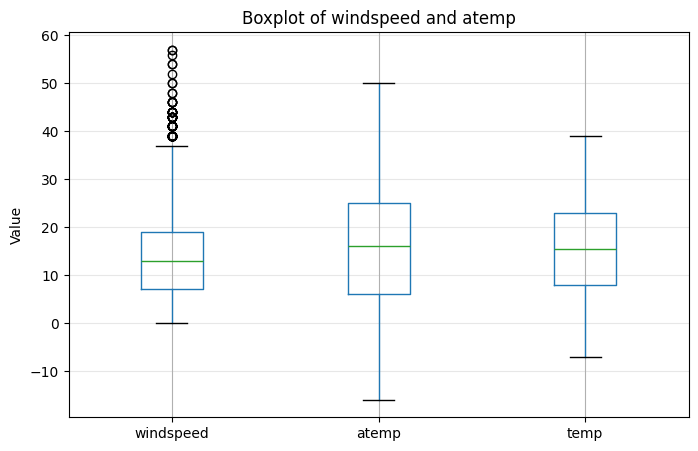

In [16]:
plt.figure(figsize=(8, 5))
train_df[["windspeed", "atemp", "temp"]].boxplot()
plt.title("Boxplot of windspeed and atemp")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [28]:
Q1 = train_df['windspeed'].quantile(0.25)
Q3 = train_df['windspeed'].quantile(0.75)
IQR = Q3 - Q1
top_whisker = Q3 + 1.5 * IQR

# 2. Count how many rows are ABOVE this whisker (these are the black dots)
number_of_black_dots = len(train_df[train_df['windspeed'] > top_whisker])

# 3. Total number of rows in the dataset
total_rows = len(train_df['windspeed'].dropna())

# 4. Calculate percentage
true_percentage = (number_of_black_dots / total_rows) * 100

print(f"Number of black dots: {number_of_black_dots}")
print(f"Total rows: {total_rows}")
print(f"True Percentage: {true_percentage:.2f}%")

Number of black dots: 91
Total rows: 13903
True Percentage: 0.65%


> **Question:**
> 
> How did the visualization help in understanding the data?
> Which questions were answered and what hypothesis are left to be tested? 
> 
> Have you decided to remove some feature from the dataset? Why?

The graphics of 'hr', 'temp' and 'atemp' with the label 'cnt' show the previously expected behavior of these features, exhibiting their high potential to help the model in the predictions due to their correlation with the label.

Additionally, the graphics evaluating 'temp' and 'atemp' together show their high correlation. The features 'mnth' and 'season' present a similar behavior. Therefore, selecting just one from each pair is probably interesting to avoid future problems with model convergence. Lacking a more precise criterion, we could simply pick the one with the highest correlation with the feature - 'temp' and 'season'.

Moreover, the boxplot reveals the presence of outliers in the windspeed feature, while the previously suspicious 'atemp' is better behaved than expected. More specifically, the percentage of outliers in windspeed is 0.65%. From this point on, we basically have two options: either delete the samples with outliers, or keep them. Initially, we decided to keep them, because this feature is not highly correlated with the label, so its final impact on the model prediction should not be considerably negative. However, we could only be sure by proceeding to the next steps. Anyway, it is relevant to highlight that the presence of outliers in data makes the use of a standard scaler even more important.

----
### **Preprocessing**
(1.0 point) Now that you have a deeper insight about the problem, let's preprocess
the raw data with the necessary transformations and turn the data into an array,
ready to be fed into a model.

Create a function `preprocess_data` and make all required transformation, the
output must be a tuple (X, y) of numpy arrays, where X has shape (n_samples, n_features)
and y is a column array of shape (n_samples,).

Note that the distributions on the features in the test set may not coincide
with the ones in the train set, your preprocessing must take that into account
without peeking at test samples.

In [32]:
train_df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [41]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()

    leakage_cols = ['casual', 'registered']
    redundant_cols = ['instant', 'dteday']
    highly_corr_cls = ['atemp', 'mnth'] # atemp highly correlated with temp; mnth highly correlated with season
    cols_to_drop = leakage_cols + redundant_cols + highly_corr_cls
    df_clean = df_clean.drop(columns=cols_to_drop)

    y = df_clean['cnt'].to_numpy()
    X = df_clean.drop(columns=['cnt'])
    return X, y

---

## **Linear Regression**

Linear regression is a simple model that assumes a linear relationship between
the observed features and the target.
Specifically, given an observation $(x_1, x_2, \dots, x_n)$, we assume there exist
a set of weights $\beta_0, \beta_1, \beta_2, \dots, \beta_n$ such that

$$y \approx \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n.$$

Each weight $\beta_i$ measures the marginal contribution of $x_i$ to the
prediction while keeping other variables fixed.
The model assumes additive effects, meaning the influence of multiple variables
is the sum of their individual contributions unless interaction terms are
explicitly included.

For example, if raining decreases the rental count, but summer increases it, a summer
rainy day contribution is no different than the contribution of rainy plus the
contribution of summer.

We can estimate the weights $\beta_i$ by measuring a discrepancy score between
predicted values $\hat{y}$ obtained withsome weight $\beta$ and the ground-truth
value $y$, and minimizing this score.

A natural way to achieve this is by defining a distance between targets that is
differentiable. However, choosing a distance that is statistical relevant is not
trivial. Instead, we could measure what is the probability that, when given
a sample $x$ and a current weight $\beta$, the ground-truth $y$ is observed, *i.e.*

$$p(y \mid x, \beta).$$

This measures what is the probability of the ground-truth given that the model
with weights $\beta$ is the true estimator.

If we tweak the weights $\beta$ so that the probability of all ground-truths is
maximized, we obtain a well-fit model.
This is achieved by the likelihood function, under the assumption of independent
samples in the dataset.

$$\mathcal{L}(\beta) = \prod_{i=1}^n p(y^i \mid x^i, \beta).$$

Indicating that a estimator $\beta$ is only good if the ground-truth probabilities
are high across all the samples. As this criteria can be very small due to the
multiplication of small quantities, a common trick is to use the log likelihood
function instead, using the log properties,

$$\log \mathcal{L}(\beta) = \sum_{i=1}^n \log p(y^i \mid x^i, \beta),$$
and then minimizing $-\log \mathcal{L}(\beta)$.

This method is called Maximum Likelihood Estimation (MLE) and it is a very commonly
used estimator in Machine Learning, as we are going to see.

### **Gaussian assumption**
We cannot directly measure $p(y \mid x, \beta)$ at the moment, as we do not have
a probability distribution that links $y$ with $x$ and $\beta$ yet, but a
deterministic relationship (linear).

To introduce this probabilistic aspect, we can suppose that the approximation
between the ground-truth $y$ and the linear term $\hat{y} = \beta_0 + \beta_1 x_1 + \dots$
is only wrong by an unpredictable "error" $\epsilon$, also called a *residual*.
A common way of introducing this error is by supposing that $\epsilon$ comes from
a zero-centered normal (or Gaussian) distribution,
*i.e.* $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

The relationship between $y$, $x$ and $\beta$ are now intermediated by $\epsilon$,

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon.$$

This makes $y$ to be a random variable centered at our linear predicition, deviated
by a random quantity, with fixed standard deviation $\sigma$ (homoscedastic).
This assumption is called **Gaussian assumption**, and has interesting properties
that intersect with the Ordinary Least Squares method, including the criterion.

With this assumption, we can measure $p(y \mid x, \beta)$ directly using the
Normal probability distribution function

$$p(y \mid x, \beta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(- \frac{(y - x^T\beta)^2}{2\sigma^2}\right),$$

$$\log p(y \mid x, \beta) =  - \frac{(y - x^T\beta)^2}{2\sigma^2} - \log(\sqrt{2\pi\sigma^2}).$$

Thus, minimizing $-\log \mathcal{L}(\beta)$, yield to

$$-\log \mathcal{L}(\beta) \propto \sum_{i=1}^n (y^i - {x^i}^T\beta)^2 = \sum_{i=1}^n (y^i - \hat{y}^i)^2 $$

Which is equivalent to the Mean Squared Error (MSE) criterion.

### **Implementation**

(0.5 points) Under the statistical lens of Linear Regression, we have also
derived the same loss function as ordinary least squares method. Now it's time to
implement the `fit` method using **gradient descent** without using any machine
learning library.


Also, complete the following metric functions with their implementations and run
your model for different learning rates

In [50]:
def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_true - y_pred) ** 2)
    # Total sum of squares
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
            return 0.0
        
    return float(1 - (ss_res / ss_tot))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

class LinearRegression:
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: np.ndarray | None = None
        self.bias: float | None = None

    def fit(self, X: pd.DataFrame, y: np.ndarray) -> None:
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        for _ in range(self.n_iterations):
            # Forward pass (compute predictions)
            y_pred = np.dot(X, self.weights) + self.bias
            
            # Compute gradients
            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        assert self.weights is not None and self.bias is not None, "Model is not trained yet"
        return np.dot(X, self.weights) + self.bias

In [51]:
def plot_results(lrs: list[float], performances: dict[str, list[float]]) -> None:
    n_metrics = len(performances)

    fig, ax = plt.subplots(figsize=(5 * n_metrics, 5), ncols=n_metrics)

    for i, (metric_name, metric_values) in enumerate(performances.items()):
        ax[i].plot(lrs, metric_values, marker="o")
        ax[i].set_xlabel("Learning Rate")
        ax[i].set_title(metric_name)
        ax[i].grid()
    
        ax[i].set_xscale("log")

    plt.tight_layout()
    plt.show()


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder

def create_preprocessor(X_train: pd.DataFrame):
    """
    Creates a scikit-learn ColumnTransformer based on feature types and cardinality.
    """
    # Identify numerical and categorical columns
    numerical_cols = X_train.select_dtypes(include=['float64', 'float32']).columns.tolist()
    categorical_cols = X_train.select_dtypes(include=['int64', 'int32', 'object']).columns.tolist()

    # Split categorical columns based on the < 7 rule
    ohe_cols = []
    target_enc_cols = []
    
    for col in categorical_cols:
        if X_train[col].nunique() < 7:
            ohe_cols.append(col)
        else:
            target_enc_cols.append(col)

    print(f"Numerical features (StandardScaler): {numerical_cols}")
    print(f"Low-cardinality features (OHE): {ohe_cols}")
    print(f"High-cardinality features (Target Encoding): {target_enc_cols}")

    # Define the transformers
    # sparse_output=False is CRITICAL here so your custom Numpy model doesn't crash
    # drop='first' prevents multicollinearity in Linear Regression
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ohe_cols),
            ('target', TargetEncoder(target_type='continuous'), target_enc_cols)
        ],
        remainder='passthrough' # Keeps any columns that didn't fit the above rules
    )
    
    return preprocessor

Numerical features (StandardScaler): ['temp', 'windspeed']
Low-cardinality features (OHE): ['season', 'yr', 'holiday', 'workingday', 'weathersit']
High-cardinality features (Target Encoding): ['hr', 'weekday', 'hum']
Lrs to test: [1.00000000e-10 3.16227766e-09 1.00000000e-07 3.16227766e-06
 1.00000000e-04 3.16227766e-03 5.00000000e-02 1.00000000e-01]


/tmp/ipykernel_50811/2865968672.py:37: RuntimeWarning: overflow encountered in dot
  dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
/tmp/ipykernel_50811/2865968672.py:37: RuntimeWarning: invalid value encountered in dot
  dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
/tmp/ipykernel_50811/2865968672.py:41: RuntimeWarning: invalid value encountered in subtract
  self.weights -= self.learning_rate * dw
/home/caio_porto/miniconda3/envs/ml_venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_50811/2865968672.py:34: RuntimeWarning: invalid value encountered in dot
  y_pred = np.dot(X, self.weights) + self.bias



mse: [np.float64(44939.12), np.float64(15196.01), np.float64(13410.74), np.float64(13052.04), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
r2_score: [-0.61, 0.45, 0.52, 0.53, nan, nan, nan, nan]
mae: [144.87, 94.54, 81.75, 80.51, nan, nan, nan, nan]

y range: 1 - 957
y mean: 174.63914263108683


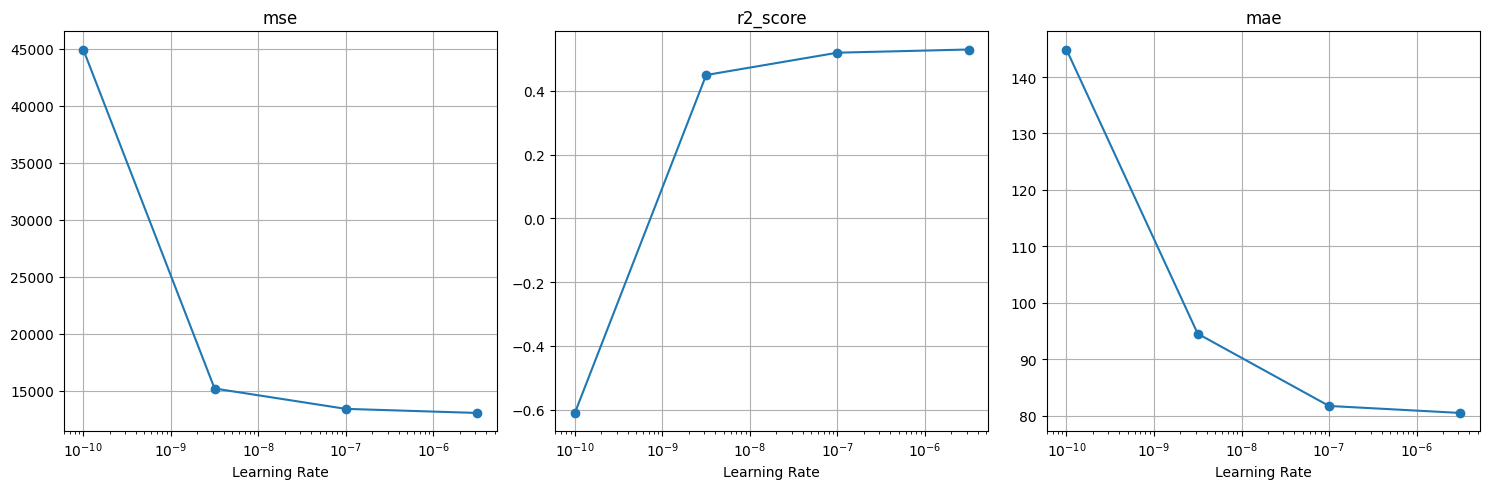

In [86]:
X, y = preprocess_data(train_df)
preprocessor = create_preprocessor(X)

X_processed = preprocessor.fit_transform(X, y)

# You can experiment with a pre-defined set of learning rates or
# with a range of learning rates (e.g. logarithmically spaced)
log_lrs = np.logspace(-10, -1, num=7)
custom_lrs = np.array([0.05])
lrs = np.sort(np.concatenate((log_lrs, custom_lrs)))
print(f"Lrs to test: {lrs}")

performances = {
    "mse": [],
    "r2_score": [],
    "mae": [],
}

for lr in lrs:
    model = LinearRegression(learning_rate=lr, n_iterations=10000)
    model.fit(X_processed, y)
    y_pred = model.predict(X_processed)

    mse_score = round(mse(y, y_pred), 2)
    r2 = round(r2_score(y, y_pred), 2)
    mae_score = round(mae(y, y_pred), 2)

    performances["mse"].append(mse_score)
    performances["r2_score"].append(r2)
    performances["mae"].append(mae_score)

print()
for key, val in performances.items():
    print(f"{key}: {val}")

print(f"\ny range: {min(y)} - {max(y)}")
print(f"y mean: {y.mean()}")

plot_results(lrs, performances)



> **Question:**
>
> How did the model perform for different learning rates?
> What happened when the learning rate was too small or too large?
>
> Interpret the metric values obtained.
Is the prediction error small relative to the scale of the target variable?
>
> Propose at least one hypothesis explaining the observed error.

The performance of the model was very sensitive to the learning rate, exhibiting a narrow window for stable convergence. When the learning rate was too small (1e-10), the steps were so small that the model barely updated its weights, resulting in a negative R² score (-0.61) and a high Mean Squared Error. As the learning rate increased toward 3.16e-06, the model achieved its best stable performance. However, any rate at or above 1e-04 proved to be too large, causing the gradients to explode. This created a mathematical overflow that produced NaN values, indicating that the loss landscape was too steep for these larger step sizes to safely navigate.

In its most stable configuration, the model yielded an R² score of 0.53 and a Mean Absolute Error (MAE) of roughly 81. Considering that the label 'cnt' ranges from 1 to 957, an average error of 81 bikes is quite large. While this value might seem small compared to the maximum of 957, it is a considerable percentage of the average value (174), meaning the prediction error is substantial relative to the typical scale of the target. A hypothesis for this error is that the Linear Regression model is too rigid to capture the non-linear behavior of this dataset. For instance, the relationship between the feature 'hr' and the label is cyclical, so a strictly linear model struggles to map these curves, leaving a gap in performance.

---
### **Visualizing Predictions**

(1.0 points) Numerical metrics summarize model quality, but visual diagnostics reveal structural problems that scalar measures may hide. Two standard visual tools are the predicted vs. observed plot and the Q–Q plot of residuals.

Choose a model from the previous session to analyse further here.

#### **Predicted vs. Observed Plot**

A direct way to evaluate prediction quality is to compare the predicted values with the true observations.
For each sample, plot the pair `(y, y_pred)`, the ideal predictor would have
perfectly match predictions, yielding all points in the line y = x in the graph.

However, this is often not the case, as prediction can go wrong.
This plot help us interpret points that are closer to the x=y line as better
predictions, and points further from this line as bad predictions.

If the overall shape of the points does not follow the line, we may have a
**systematic error**, indicating model misspecification.

By coloring each point by some other characteristic, we can also see if the error
is systematic with respect to that characteristic.
For example, the model mispredicts some seaons more than others.

You can explore more plots to get an insight on why and how is your model fit.

In [76]:
def pred_vs_true_plot(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    _, ax = plt.subplots(figsize=(10, 6))

    ax.grid()
    ax.scatter(y_true, y_pred, alpha=0.5)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--', label='Ideal Fit')
    ax.set_xlabel("True Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title("Predicted vs True Values")
    ax.legend()
    plt.show()

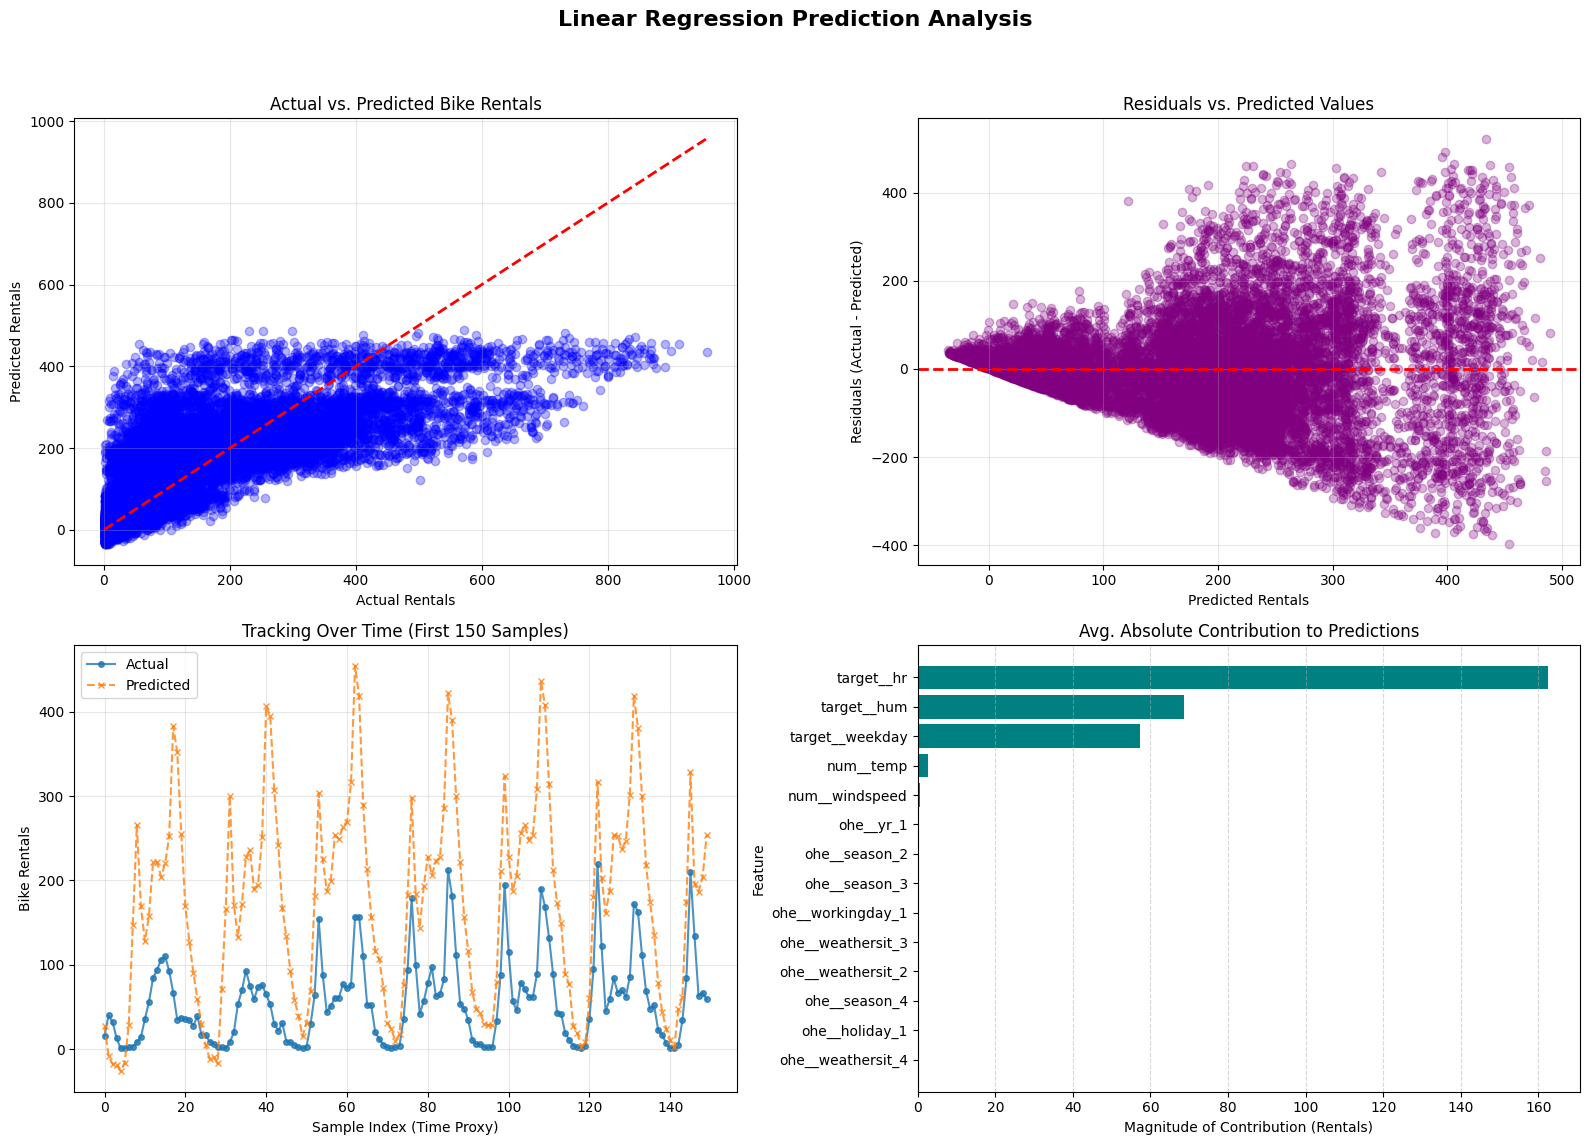

In [ ]:
# Explore more plots to analyze the predictions, e.g., predictions vs time, contribution of each feature to the predictions, etc.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_prediction_analysis(model, X_val, y_val, feature_names):
    """
    Generates a 2x2 grid of diagnostic plots to analyze linear regression predictions.
    """
    # Generate predictions and residuals
    y_pred = model.predict(X_val)
    residuals = y_val - y_pred
    
    # Calculate Feature Contributions
    # Contribution = feature_value * feature_weight
    # We take the mean absolute contribution across the validation set
    contributions = X_val * model.weights
    mean_abs_contrib = np.mean(np.abs(contributions), axis=0)
    
    # Sort contributions for the bar plot
    contrib_df = pd.DataFrame({
        'Feature': feature_names,
        'Avg_Abs_Contribution': mean_abs_contrib
    }).sort_values(by='Avg_Abs_Contribution', ascending=True)

    # Matplotlib figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Linear Regression Prediction Analysis', fontsize=16, fontweight='bold')

    # --- Plot 1: Actual vs. Predicted ---
    axes[0, 0].scatter(y_val, y_pred, alpha=0.3, color='blue')
    # Plot the "perfect prediction" diagonal line
    axes[0, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    axes[0, 0].set_title('Actual vs. Predicted Bike Rentals')
    axes[0, 0].set_xlabel('Actual Rentals')
    axes[0, 0].set_ylabel('Predicted Rentals')
    axes[0, 0].grid(True, alpha=0.3)

    # --- Plot 2: Residuals vs. Predicted ---
    axes[0, 1].scatter(y_pred, residuals, alpha=0.3, color='purple')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 1].set_title('Residuals vs. Predicted Values')
    axes[0, 1].set_xlabel('Predicted Rentals')
    axes[0, 1].set_ylabel('Residuals (Actual - Predicted)')
    axes[0, 1].grid(True, alpha=0.3)

    # --- Plot 3: Time-Series Tracking (Slice) ---
    # Plotting just the first 150 points to see how well the model tracks peaks and valleys
    slice_length = min(150, len(y_val))
    axes[1, 0].plot(y_val[:slice_length], label='Actual', marker='o', markersize=4, linestyle='-', alpha=0.8)
    axes[1, 0].plot(y_pred[:slice_length], label='Predicted', marker='x', markersize=4, linestyle='--', alpha=0.8)
    axes[1, 0].set_title(f'Tracking Over Time (First {slice_length} Samples)')
    axes[1, 0].set_xlabel('Sample Index (Time Proxy)')
    axes[1, 0].set_ylabel('Bike Rentals')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # --- Plot 4: Average Absolute Feature Contribution ---
    axes[1, 1].barh(contrib_df['Feature'], contrib_df['Avg_Abs_Contribution'], color='teal')
    axes[1, 1].set_title('Avg. Absolute Contribution to Predictions')
    axes[1, 1].set_xlabel('Magnitude of Contribution (Rentals)')
    axes[1, 1].set_ylabel('Feature')
    axes[1, 1].grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Execution Example ---
best_model = LinearRegression(learning_rate=3.16e-06, n_iterations=10000)
best_model.fit(X_processed, y)

feature_names = preprocessor.get_feature_names_out()
plot_prediction_analysis(best_model, X_processed, y, feature_names)

> **Question:**
>
> Based on your visualizations, do you observe systematic deviations
(for example curvature or clusters)?
>
> If systematic patterns exist, what do they suggest about the relationship between
the predictors and the target?
>
> Does this visualization support or contradict the hypotheses you proposed earlier?

The graphics reveal that while the model successfully captures the cyclical behavior of the data, it struggles with the magnitude, leading to systematic deviations. As shown in the "Tracking Over Time" plot, the model correctly anticipates when demand will rise and fall, but it over-predicts the volume, frequently overshooting the 'cnt' values during high-traffic periods. This behavior, combined with the spread observed in the residuals, suggests that the relationship between the features and the label is not strictly linear. Instead, it indicates that the features interact in complex ways that a rigid linear model cannot perfectly scale.

These patterns support the previously proposed hypothesis regarding the non-linear behavior of the features. The "Tracking Over Time" plot illustrates this limitation: rather than missing the peaks, the linear model overreacts to them. If features like 'hr' and 'temp' are the most important drivers, the linear model is forced to assign them heavy weights. Because 'hr' is inherently cyclical and demand has a saturation point, forcing these variables into a linear equation prevents the model from "tapering off" its predictions, resulting in the exaggerated peaks and systematic residual clusters observed here.

---
#### **Residual Analysis**
(1.0 points) As discussed above, a main assumption we have made is the nature of $\epsilon$ to
be Gaussian.

These error values are now computable by the difference between the ground-truth and
the predicted values

$$r_i = y - \hat{y} \sim \mathcal{N}(0, \sigma)$$

Therefore, if our linear regression model is correct, we can observe normally
distributed residuals across the dataset.
One way of checking how normally is distributed our distribution is by a
quantile–quantile (Q–Q) plot.

This plot compares the empirical distribution of residuals with the theoretical quantiles of a reference distribution (usually the normal distribution).

To do this, we sort the residuals, compute the theoretical quantiles and plot they along
so each point (r_i, q_i) compares the observed residual and the quantile if the
distribution were normally distributed.

Similarly to the previous plot, if the points follow the line y=x, the quantiles
are well aligned with the empirical distribution, suggesting a good fit.
However, curvatures may represent skews in the distribution, usually indicating
that the distribution is not normal.

In [88]:
def q_q_plot(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    residuals = y_true - y_pred

    sorted_residuals = np.sort(residuals)
    theoretical_quantiles = np.sort(np.random.normal(loc=0, scale=np.std(residuals), size=len(residuals)))

    plt.figure(figsize=(10, 6))
    plt.grid()
    plt.scatter(theoretical_quantiles, sorted_residuals, alpha=0.5, s=10, label='Residuals')
    plt.plot([theoretical_quantiles.min(), theoretical_quantiles.max()], [theoretical_quantiles.min(), theoretical_quantiles.max()], color='red', linestyle='--', label='Ideal Fit')
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Ordered Residuals")
    plt.title("Q-Q Plot of Residuals")
    plt.legend()
    plt.show()

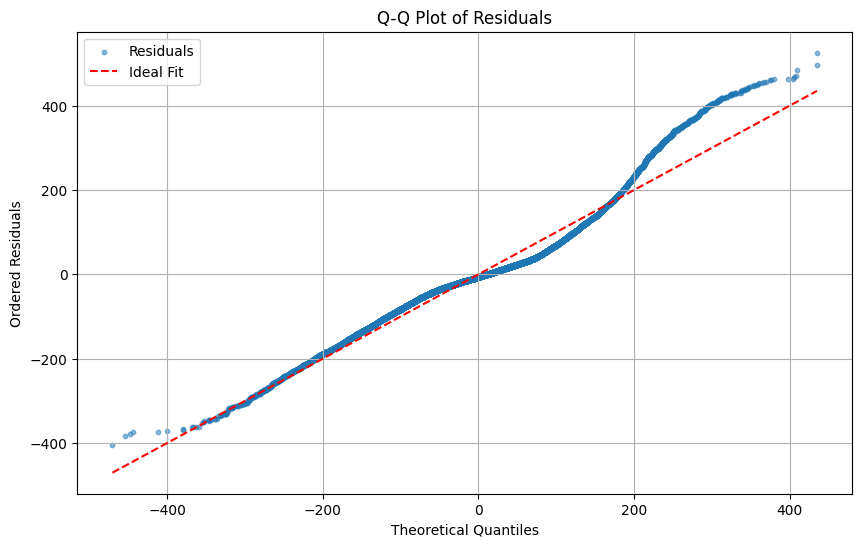

In [84]:
q_q_plot(y, y_pred)

> **Question:**
>
> Are the points approximately aligned along a straight line?
>
> What does this indicate about the Gaussian noise assumption used to derive
the MSE objective?
> 
> Based on the evidence from the metrics and plots,
> is linear regression an appropriate model for this dataset?
>
> Justify your conclusion.

Based on the Q-Q plot, the points are not aligned along the straight line. Instead, they exhibit a considerable deviation, particularly at the upper right tail. This curvature indicates that the error distribution has a "heavy right tail," meaning the model is producing large positive errors more frequently than a normal distribution would. Therefore, this skew violates the Gaussian noise assumption that justifies the use of MSE, proving that the statistical premise of this regression setup does not hold for the data.

Given this evidence, standard linear regression is not appropriate for this dataset. This is supported by the diagnostics: the $R^2$ value was bad, earlier graphics showed clear variation of the residuals, and the Q-Q plot confirms the residuals are non-normal. Since the label 'cnt' has a floor at zero but presents spikes during peak demand, a rigid linear model fails to map these peaks correctly.

---

## **Polynomial Models**


Linear regression assumes that the relationship between the features and the
target is linear.
However, in many real-world situations the relationship between
a variable and the output may be curved or more complex.

For example, suppose that the number of bike rentals increases with temperature
up to a comfortable level, but then decreases when the weather becomes too hot.
A straight line would not be able to capture this behavior.

One way to increase the flexibility of linear regression is to transform the
input features.
Instead of using raw variables $x_i$, we can include higher
powers of it, creating new features such as $x_i^2$, $x_i \cdot x_j$, and so on.

For instance, a quadratic model can be written as

$$y \approx \beta_0 + \beta_1 x + \beta_2 x^2.$$

Although this model is nonlinear with respect to the original variables,
it is still **linear in the parameters** $\beta$.
Because of this, the same training methods used for linear regression can still
be applied.

The effect is an increased set of possible models that can describe the relationship
between $x$ and $y$ via parameters $\beta$.

In practice, polynomial regression is implemented by **expanding the feature
space**.
For example, if the original input is $(x_1, x_2)$, apolynomial expansion of
degree two could produce the new feature vector

$$(x_1, x_2, x_1^2, x_2^2, x_1 x_2).$$

The regression model is then applied to this expanded set of features.
This transformation allows the model to capture nonlinear relationships while
keeping the optimization problem simple.

### **Model Capacity and Overfitting**

Increasing the polynomial degree increases the **capacity** of the model. A
higher-degree polynomial can represent more complex relationships in the data.

However, a model that is too flexible may start fitting the noise present in
the training data instead of the underlying relationship. This phenomenon is
called **overfitting**.

As the polynomial degree increases:

- The training error usually decreases.
- The test error may start increasing after a certain point.

This happens because the model becomes too specialized to the training dataset.

### **Implementation**

(1.0 points) Implement the `polynomial_expansion` function that expands the input features
to polynomial features of degree at most $d$.

Instead of using only the original variables, now include polynomial terms with
different degree values, for example, $d = 2, 3, \dots$.
This makes the model more flexible and can represent non-linear relationships
between the predictors and the target.

Remember to test for different learning rates, similar to what was done previously.

In [ ]:
def polynomial_expansion(X: NDArray[np.float_], d: int) -> NDArray[np.float_]:
    raise NotImplementedError(
        "Implement this function to perform polynomial expansion of the features up to degree d"
    )

In [ ]:
# Implement and train the polynomial regression models here using the 
# polynomial_expansion function to transform the features before training the linear regression model.

# Experiment with different degrees and analyze the results to choose the best combination
# of learning rate and degree for the polynomial regression model.

> **Question:**
> 
> How does the training error of the polynomial model compare with the
training error of the linear regression model?
>
> Does this result indicate that it is better than the linear
model for this problem?
>
> Which degree would you select to explore?

*YOUR ANSWER HERE*

---
### **Visualizing Predictions**

(1.5 points) Inspect the predicted vs observed plot, compare with the same plots used in the
linear model, are they different?

Explore how the results change and link them with training error in the polynomial
model.

In [ ]:
best_lr = 1 # Choose the best learning rate based on the previous graphs
best_degree = 100 # Choose the best degree based on experimentation with different degrees and analyzing the results

X_poly = polynomial_expansion(X, best_degree)

best_poly_model = LinearRegression(learning_rate=1, n_iterations=10000)
best_poly_model.fit(X_poly, y)
y_pred = best_poly_model.predict(X_poly)

pred_vs_true_plot(y, y_pred)

In [ ]:
q_q_plot(y, y_pred)

In [ ]:
# Plot other visualizations too to better analyze the predictions.

> **Question:**
> 
> Does the polynomial model appear to capture relationships that the linear model
could not?
>
> Did this choice fixed the systematic deviations previously observed?


*YOUR ANSWER HERE*

---
## **Count Data and Model Assumptions**

> **IMPORTANT:** This section is optional and will yield **additional 1.0 points**
> to your assignment.
> We reccomend you to finish the mandatory sections above before attempting to
> switch to additional assumptions and model decisions this section introduces.
>
> Despite this section being optional, we strongly advise you on exploring
> the following models, not only as an additional model to your toolbox, but
> from the modeling perspective of statistical learning.

\
In the previous sections we used linear regression and polynomial models
to predict the number of bike rentals.
However, the target variable in this dataset has a particular characteristic,
it represents a **count**.

This is important because, when we were stating the assumptions in the linear model,
we had no hard assumption on the target nature, it was a real number.
In counting problems, the target is a positive integer number with specific
characteristics that are ignored.

Therefore, a possible direction of improvement is choosing the model that best
aligns with our problem, exploiting the domain knowlegde we have to produce better
estimators.

In this section, we are going to use a new linear model with a different
probabilistic assumption for the target variable.

### **Poisson distribution**

A common model for count data is the **Poisson distribution**.
This distribution describes the probability of observing a number of events
during a fixed interval.

For example, the number of students achieving a low and high mark in an exam,
the number of meteorites that strike Earth in a year.

The Poisson distribution is parameterized by a rate parameter $\lambda > 0$,
which represents the expected number of events in a time unit.

The probability of observing a value $y$ is

$$p(y \mid \lambda) = \frac{\lambda^y e^{-\lambda}}{y!}.$$

In this model, both the mean and the variance are equal to $\lambda$.
Therefore, when predicting, returning the expected count value $\hat{y}$ is
equivalent to returning $\lambda$ itself.

### **Poisson Regression**
Poisson regression is a special case of the Generalized Linear Models along with
Linear and Logistic regression.
The idea here is to model $\lambda$ as a function of the input $x$ and parameters
$\beta$ and describe $p(y \mid x, \beta) = p(y \mid \lambda)$.

Again, as a linear model, we want to relate the linear combination
$\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$ to this new parameter $\lambda$,
that is strictly positive.

To make this to happen, we define a **link function** $g$ such that $g(\lambda)$
can vary from -$\infty$ to $\infty$, thus allowing that

$$g(\lambda) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n,$$
as $\beta$ and $x$ are unconstrained.

A common link function used in Poisson regression is the $\log$, making

$$\hat{y} = \lambda = \exp(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n),$$
turning the previously unconstrained prediction in a strictly positive count
parameter, and then addressing a probability using the Poisson distribution.

#### **Implementation**

(1.0 points) Derive the loss function of the Poisson Regression,

$$-\log \mathcal{L}(\beta) = -\sum_{i=1}^n \log p(y^i \mid x^i, \beta),$$
using the Poisson distribution instead of the Gaussian distribution for $p(y^i \mid x^i, \beta)$.

**Hint:** You can ignore constant terms and scales in the objective function to
obtain a MSE-like gradient.

> **Question:**
>
> Is the negative log-likelihood the same?
>
> Is it equivalent to a Linear regressor predicting $\log y$ instead of $y$?

*YOUR ANSWER HERE*

---
Implement this regression using the same pattern as the `LinearRegression` and
train a Poisson regression model using the same training dataset used
previously, selecting appropriate learning rates.

In [ ]:
class PoissonRegression:
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: NDArray[np.float_] | None = None
        self.bias: float | None = None

    def fit(self, X: NDArray[np.float_], y: NDArray[np.float_]) -> None:
        n_samples, n_features = X.shape
        weights = np.zeros(n_features)
        bias = 0.0

        raise NotImplementedError(
            "Implement this function to train the linear regression model using gradient descent"
        )
    
    def predict(self, X: NDArray[np.float_]) -> NDArray[np.float_]:
        assert self.weights is not None and self.bias is not None, "Model is not trained yet"

        raise NotImplementedError(
            "Implement this function to make predictions using the trained linear regression model"
        )


In [ ]:
# Implement and train the poisson regression models here.

> **Question:**
>
> Compare the performance of the Poisson models with the Linear Regression model.
> Even though both models rely on a linear combination of the features,
> their predictions are not computed in the same way.
>
> $\hat{y}=x^T\beta$
>
> $\lambda=\exp(x^T\beta)$
>
> Are the predictive performances equivalent?
> Which model appears to produce predictions that better match the data?
>
> Explain why two models that both use a linear predictor can still behave
> very differently. Consider the distributional assumptions and the
> transformation applied to the output.

*YOUR ANSWER HERE*

---
### **Visualizing Predictions**

Check how the predictions change when moving from the **Gaussian assumption**
used in linear regression to the **Poisson assumption** used in Poisson regression.

Plot the predicted values against the observed values and compare the
distribution of points with the plots obtained previously.

Pay attention to how the **shape of the point cloud** changes under the
different modeling assumptions.


In [ ]:
best_lr = 1 # Choose the best learning rate based on the previous graphs

best_poisson_model = PoissonRegression(learning_rate=best_lr, n_iterations=10000)
best_poisson_model.fit(X, y)
y_pred = best_poisson_model.predict(X)

pred_vs_true_plot(y, y_pred)

In [ ]:
# Plot other visualizations too to better analyze the predictions.

> **Question:**
>
> Compare the prediction plots obtained with the **Linear**, **Polynomial**, and
> **Poisson** models.
>
> - Does the Poisson model change the overall shape of the prediction cloud?
> - Do the predictions appear more consistent with the count nature of the data?
> - Are extreme values predicted differently?
>
> Based on the visualization, what differences arise from changing the
> probabilistic assumption of the model?

*YOUR ANSWER HERE*

---
### **Residual Diagnostics for Poisson Regression**

In the previous sections we used a **Q–Q plot** to evaluate whether the
residuals followed a **Normal distribution**. This diagnostic was meaningful
because linear regression was derived under the assumption that the error term
follows a Gaussian distribution,

$$\epsilon \sim \mathcal{N}(0,\sigma^2).$$

Under this assumption, if the model is well specified, the residual

$$r_i = y_i - \hat{y}_i,$$
should also resemble a Normal distribution.

The Q–Q plot therefore allowed us to visually verify whether this assumption was
reasonable.
However, this reasoning no longer applies to **Poisson regression**, as the
target $y$ now is assumed to be drawn from a Poisson distribution with

$$y \sim \text{Poisson}(\lambda), \qquad \lambda = \exp(x^T\beta).$$

Because of this, the residuals are **not expected to follow a Normal
distribution**, even if the model is correct.
A Q–Q plot comparing them to a Normal distribution therefore does not test a
relevant assumption.


---
### **Polynomial Poisson Regression**

As we observed an increased performance by introducing polynomial
features, allowing the model to capture nonlinear relationships between the
predictors and the target.
The same idea can be applied to **Poisson regression**.

Instead of changing the probabilistic model, we only change the
**feature representation**. The Poisson model still assumes that the
expected count follows an exponential transformation of a linear
predictor,

$$\lambda = \exp(x^T\beta).$$
with $x$ now containing polynomial terms.

Continue exploring Poisson models with more complex relationships, find the best
degrees and learning rates.


In [ ]:
# Implement and train the polynomial poisson regression models here using the 
# polynomial_expansion function to transform the features before training the linear regression model.

# Experiment with different degrees and analyze the results to choose the best combination
# of learning rate and degree for the polynomial regression model.

In [ ]:
best_lr = 1 # Choose the best learning rate based on the previous graphs
best_degree = 100 # Choose the best degree based on experimentation with different degrees and analyzing the results

X_poly = polynomial_expansion(X, best_degree)

best_poisson_poly_model = PoissonRegression(learning_rate=best_lr, n_iterations=10000)
best_poisson_poly_model.fit(X_poly, y)
y_pred = best_poisson_poly_model.predict(X_poly)

pred_vs_true_plot(y, y_pred)

> **Question:**
>
> Compare the residual structure of the **Poisson** and
> **Polynomial Poisson** models.
>
> Was the improvement similar to the Linear Regression counterparts?
> How are they different?

*YOUR ANSWER HERE*

---
## **Final Model Comparison**


Until this point, all analysis and decisions were made using only the **training data**.  
The **test dataset** has remained untouched so that it can provide an unbiased
evaluation of the final models.

This is important in machine learning, as our job is not train a model that can
copy the behavior in data, but to generalize to unseen observations.
The decisions made to improve the performance based only on training data may or
may not reflect in the test data, indicating a under or overfitting.

(1.0 points) Before using the test dataset, look at all your decisions and assumptions done
on each model and discuss them.
In real life, this would be the last step before the deployment our models.

> **Question:**
>
> Revisiting all the models you have trained, what are the main differences between them in performance and assumptions?
> 
> If you could select only one, based on your analysis, which one would you choose and why?
> Also discuss about its possible limitations, what it doesn't solve?
>
> How do you think it will perform on unseen data?

*YOUR ANSWER HERE*

---

(0.5 points) Now evaluate all trained models on the **test dataset** using the same metrics
used previously.
Compute the predictions and compare their performance.

In [ ]:
# Comparison code here, make sure you have the final models

In [ ]:
X_test, y_test = preprocess_data(test_df)

# You can create plots comparing the predictions of the different models, e.g., predicted vs true values for each model, residual plots, etc.
# Measure the performance of each model using the implemented metrics and compare them in a table or bar plot.
# Feel free to explore other ways to compare the models and analyze their predictions.




> **Question:**
>
> Compare the performance of all models on the **test dataset**.
>
> Are the differences between the models large or small?
> 
> Does the test behave the same as the train results?
> Did you make the right choices when you selected the "best" model based on the training data?
>
> Finally, make hypothesis on the whole result, why the test behave differently
from the train? What different decisions would you have made if you had access to the
test data?


*YOUR ANSWER HERE*

---
## **Assignment submission**


This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.
Before submitting, make sure that
- Your notebook runs end-to-end without errors.
- All the plots are included in the notebook.
- The notebook must be self-contained and there is no external dependency.

**Important: Only one member of the group should submit the solution.**

### **Policy for late submissions**

You are NOT encouraged to submit the solution after the deadline; however, in this case, the following penalties hold:

* 25% of the grade for 1-day late submission;
* 50% of the grade for 2-day late submission;
* 75% of the grade for 3-day late submission.